In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


print("Libraries imported successfully!")

Libraries imported successfully!


Two CSV files were provided:



*   Stress_Dataset.csv
*   StressLevelDataset.csv


We inspected both datasets before deciding which one is most suitable for the final machine learning task.

In [2]:
survey_df = pd.read_csv('https://docs.google.com/uc?export=download&id=1R16I0UlEaTTt-QQyuB2pAMyJ8lFYU_t8')
level_df = pd.read_csv('https://docs.google.com/uc?export=download&id=1xfDxmm1-cJPGj0TKql-PElZPisTBBEC8')

print("Stress_Dataset.csv shape:", survey_df.shape)
print("StressLevelDataset.csv shape:", level_df.shape)

Stress_Dataset.csv shape: (843, 26)
StressLevelDataset.csv shape: (1100, 21)


In [3]:
def inspect_dataset(df, dataset_name, target_column=None):
    print(f"\n{'=' * 80}")
    print(dataset_name)
    print(f"{'=' * 80}")
    print("Rows and columns:", df.shape)
    print("\nColumn names:")
    display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str).values}))
    print("\nMissing values:")
    display(df.isna().sum().to_frame("missing_count"))
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nNumber of unique values:")
    display(df.nunique().to_frame("unique_values"))
    if target_column is not None and target_column in df.columns:
        print(f"\nTarget distribution for {target_column}:")
        display(df[target_column].value_counts().sort_index().to_frame("count"))


inspect_dataset(
    survey_df,
    "Stress_Dataset.csv",
    target_column="Which type of stress do you primarily experience?",
)

inspect_dataset(
    level_df,
    "StressLevelDataset.csv",
    target_column="stress_level",
)


Stress_Dataset.csv
Rows and columns: (843, 26)

Column names:


,column,dtype
0,Gender,int64
1,Age,int64
2,Have you recently experienced stress in your l...,int64
3,Have you noticed a rapid heartbeat or palpitat...,int64
4,Have you been dealing with anxiety or tension ...,int64
5,Do you face any sleep problems or difficulties...,int64
6,Have you been dealing with anxiety or tension ...,int64
7,Have you been getting headaches more often tha...,int64
8,Do you get irritated easily?,int64
9,Do you have trouble concentrating on your acad...,int64



Missing values:


,missing_count
Gender,0
Age,0
Have you recently experienced stress in your life?,0
Have you noticed a rapid heartbeat or palpitations?,0
Have you been dealing with anxiety or tension recently?,0
Do you face any sleep problems or difficulties falling asleep?,0
Have you been dealing with anxiety or tension recently?.1,0
Have you been getting headaches more often than usual?,0
Do you get irritated easily?,0
Do you have trouble concentrating on your academic tasks?,0



Duplicate rows: 27

Number of unique values:


...

,missing_count
anxiety_level,0
self_esteem,0
mental_health_history,0
depression,0
headache,0
blood_pressure,0
sleep_quality,0
breathing_problem,0
noise_level,0
living_conditions,0



Duplicate rows: 0

Number of unique values:


,unique_values
anxiety_level,22
self_esteem,31
mental_health_history,2
depression,28
headache,6
blood_pressure,3
sleep_quality,6
breathing_problem,6
noise_level,6
living_conditions,6



Target distribution for stress_level:


,count
stress_level,
0,373
1,358
2,369


StressLevelDataset.csv is selected as the main modeling dataset because:


*   it has a clear target column named stress_level;
*   it has no missing values;
*   it has no duplicate rows;

Stress_Dataset.csv is still inspected as required. However, it is not selected as the main modeling dataset because it contains duplicate rows and its possible target column, Which type of stress do you primarily experience?, is highly imbalanced.

In [4]:
df = level_df
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing values per column:
anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

Total missing values: 0


In [5]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [6]:
expected_ranges = {
    'anxiety_level': (0, 21),
    'self_esteem': (0, 30),
    'mental_health_history': (0, 1),
    'depression': (0, 27),
    'headache': (0, 5),
    'blood_pressure': (1, 3),
    'sleep_quality': (0, 5),
    'breathing_problem': (0, 5),
    'noise_level': (0, 5),
    'living_conditions': (0, 5),
    'safety': (0, 5),
    'basic_needs': (0, 5),
    'academic_performance': (0, 5),
    'study_load': (0, 5),
    'teacher_student_relationship': (0, 5),
    'future_career_concerns': (0, 5),
    'social_support': (0, 3),
    'peer_pressure': (0, 5),
    'extracurricular_activities': (0, 5),
    'bullying': (0, 5),
    'stress_level': (0, 2)
}

print("Checking for out-of-range values:")
found_issues = False
for col, (low, high) in expected_ranges.items():
    out = df[(df[col] < low) | (df[col] > high)]
    if len(out) > 0:
        print(f"  {col}: {len(out)} out-of-range values")
        found_issues = True

if not found_issues:
    print("  All columns are within expected ranges — no inconsistencies found.")

Checking for out-of-range values:
  All columns are within expected ranges — no inconsistencies found.


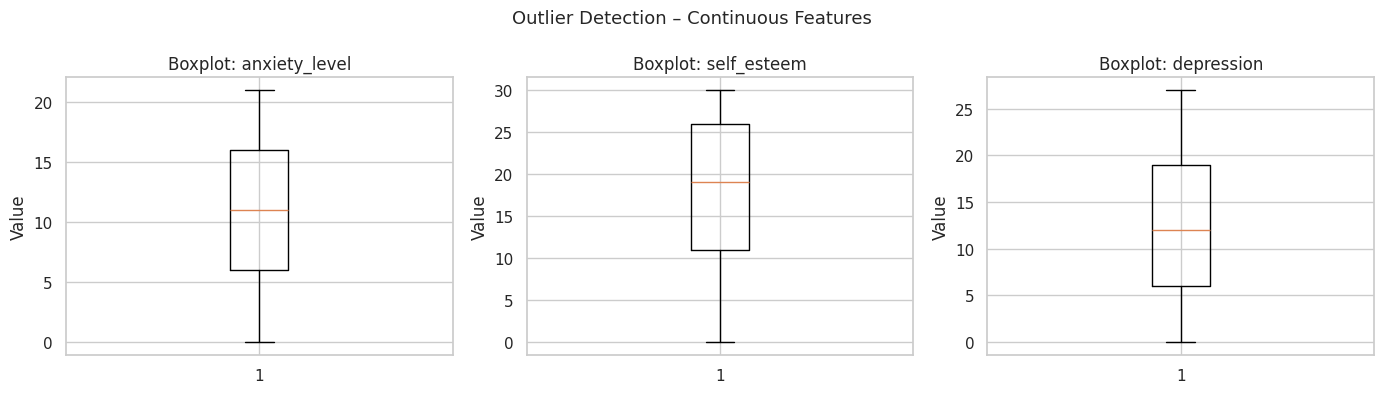

In [7]:
continuous_features = ['anxiety_level', 'self_esteem', 'depression']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, continuous_features):
    ax.boxplot(df[col])
    ax.set_title(f'Boxplot: {col}')
    ax.set_ylabel('Value')
plt.suptitle('Outlier Detection – Continuous Features', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
print("Outliers retained — they represent valid extreme responses from students.")
df_clean = df.copy()
print(f"Clean dataset shape after Stage 1: {df_clean.shape}")


Outliers retained — they represent valid extreme responses from students.
Clean dataset shape after Stage 1: (1100, 21)


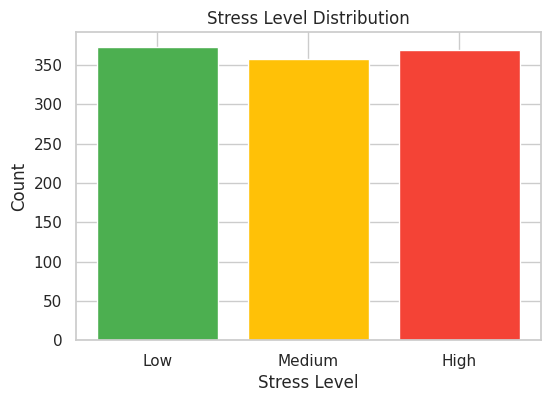

Stress Level Distribution:
  Low (0): 373 students (33.9%)
  Medium (1): 358 students (32.5%)
  High (2): 369 students (33.5%)


In [9]:
label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
counts = df_clean['stress_level'].value_counts().sort_index()
labels = [label_map[i] for i in counts.index]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts.values, color=['#4CAF50', '#FFC107', '#F44336'])
plt.title('Stress Level Distribution')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.show()

print("Stress Level Distribution:")
for k, v in label_map.items():
    print(f"  {v} ({k}): {counts[k]} students ({counts[k]/len(df_clean)*100:.1f}%)")

## Data Cleaning

Stage 1: Data cleaning - missing values, duplicate rows, expected value ranges, and outliers

Stage 2: Data transformation - feature scaling and feature engineering

Stage 3: Data reduction - feature selection and PCA

The selected dataset already has no missing values and no duplicate rows, so no rows need to be removed for those issues.

In [10]:
df = level_df.copy()

missing_total = df.isna().sum().sum()
duplicate_total = df.duplicated().sum()

print("Total missing values:", missing_total)
print("Total duplicate rows:", duplicate_total)

if duplicate_total > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicate rows found, so no duplicate removal was needed.")

Total missing values: 0
Total duplicate rows: 0
No duplicate rows found, so no duplicate removal was needed.


In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

range_summary = pd.DataFrame({
    "min": df[numeric_columns].min(),
    "max": df[numeric_columns].max(),
    "unique_values": df[numeric_columns].nunique(),
}).sort_index()

display(range_summary)

,min,max,unique_values
academic_performance,0,5,6
anxiety_level,0,21,22
basic_needs,0,5,6
blood_pressure,1,3,3
breathing_problem,0,5,6
bullying,0,5,6
depression,0,27,28
extracurricular_activities,0,5,6
future_career_concerns,0,5,6
headache,0,5,6


In [12]:
expected_ranges = {
    "anxiety_level": (0, 21),
    "self_esteem": (0, 30),
    "mental_health_history": (0, 1),
    "depression": (0, 27),
    "headache": (0, 5),
    "blood_pressure": (1, 3),
    "sleep_quality": (0, 5),
    "breathing_problem": (0, 5),
    "noise_level": (0, 5),
    "living_conditions": (0, 5),
    "safety": (0, 5),
    "basic_needs": (0, 5),
    "academic_performance": (0, 5),
    "study_load": (0, 5),
    "teacher_student_relationship": (0, 5),
    "future_career_concerns": (0, 5),
    "social_support": (0, 3),
    "peer_pressure": (0, 5),
    "extracurricular_activities": (0, 5),
    "bullying": (0, 5),
    "stress_level": (0, 2),
}

range_issues = []
for column, (lower, upper) in expected_ranges.items():
    below_count = int((df[column] < lower).sum())
    above_count = int((df[column] > upper).sum())
    range_issues.append({
        "column": column,
        "expected_min": lower,
        "expected_max": upper,
        "below_range_count": below_count,
        "above_range_count": above_count,
    })

range_issues_df = pd.DataFrame(range_issues)
display(range_issues_df)

total_range_issues = range_issues_df[["below_range_count", "above_range_count"]].sum().sum()
print("Total values outside expected ranges:", total_range_issues)

,column,expected_min,expected_max,below_range_count,above_range_count
0,anxiety_level,0,21,0,0
1,self_esteem,0,30,0,0
2,mental_health_history,0,1,0,0
3,depression,0,27,0,0
4,headache,0,5,0,0
5,blood_pressure,1,3,0,0
6,sleep_quality,0,5,0,0
7,breathing_problem,0,5,0,0
8,noise_level,0,5,0,0
9,living_conditions,0,5,0,0


Total values outside expected ranges: 0


## Exploratory Data Analysis


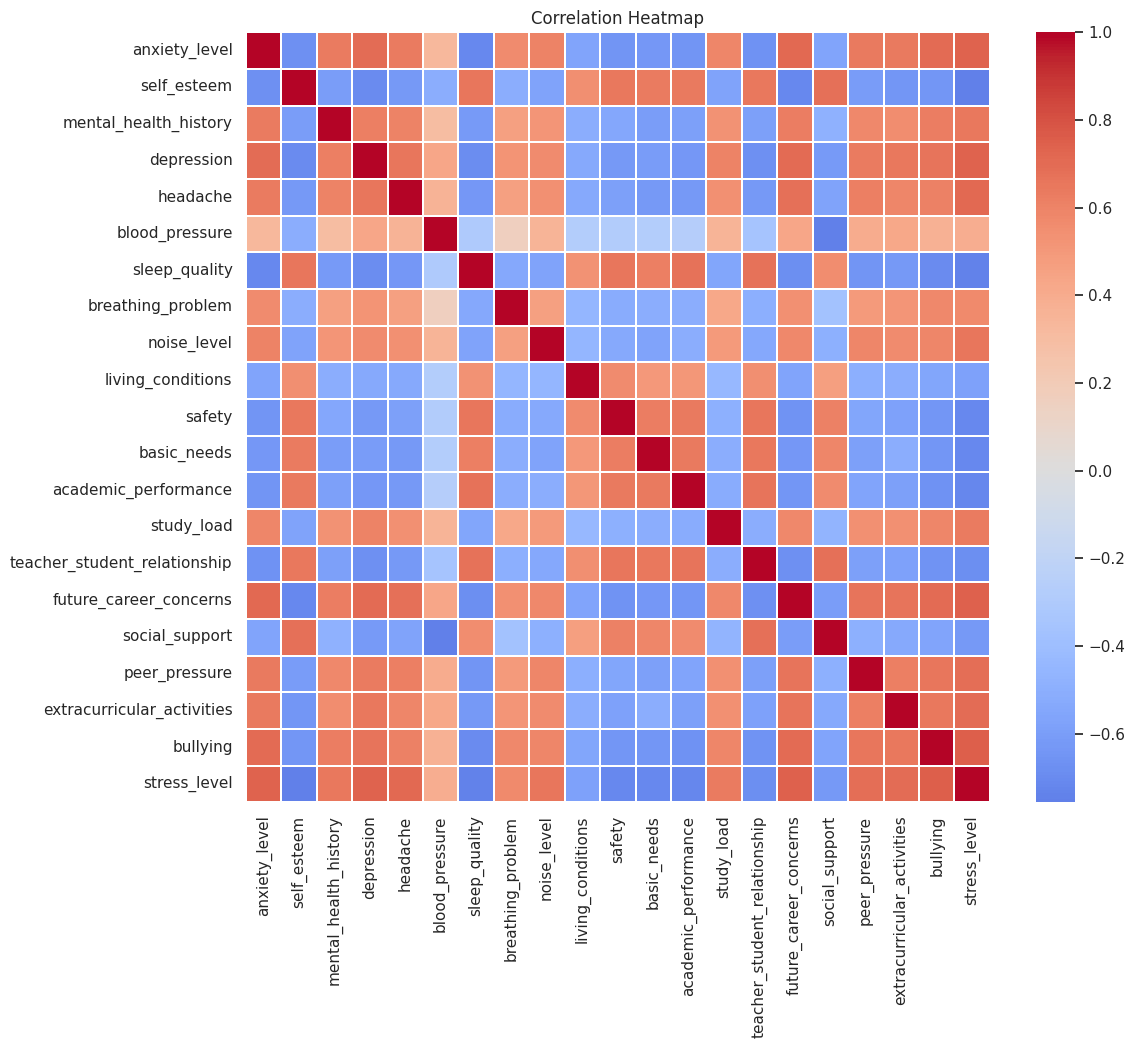

In [13]:
plt.figure(figsize=(12, 10))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap")
plt.show()

,correlation_with_stress_level
self_esteem,-0.756195
bullying,0.751162
sleep_quality,-0.749068
future_career_concerns,0.742619
anxiety_level,0.736795
depression,0.734379
academic_performance,-0.720922
headache,0.713484
safety,-0.709602
basic_needs,-0.708968


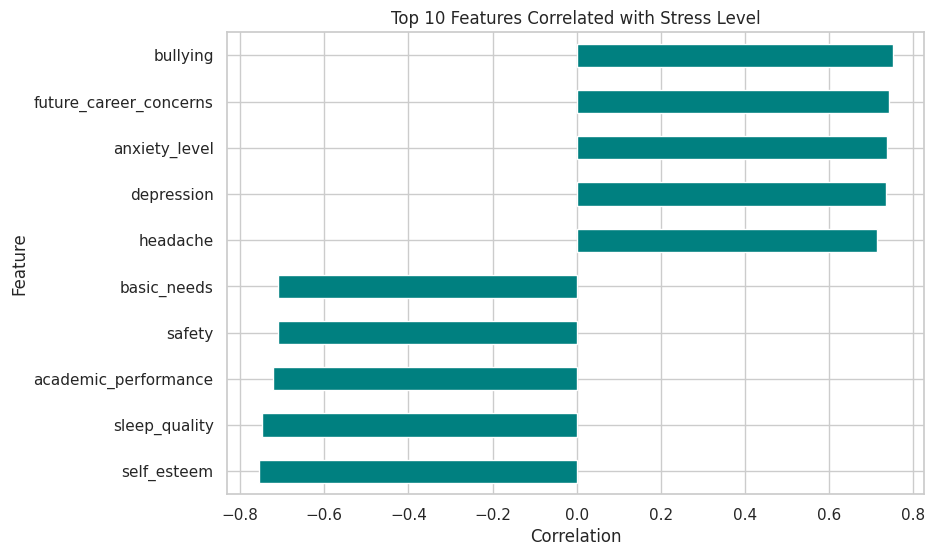

In [14]:
target_correlation = (
    correlation["stress_level"]
    .drop("stress_level")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

display(target_correlation.to_frame("correlation_with_stress_level"))

plt.figure(figsize=(9, 6))
target_correlation.head(10).sort_values().plot(kind="barh", color="teal")
plt.title("Top 10 Features Correlated with Stress Level")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

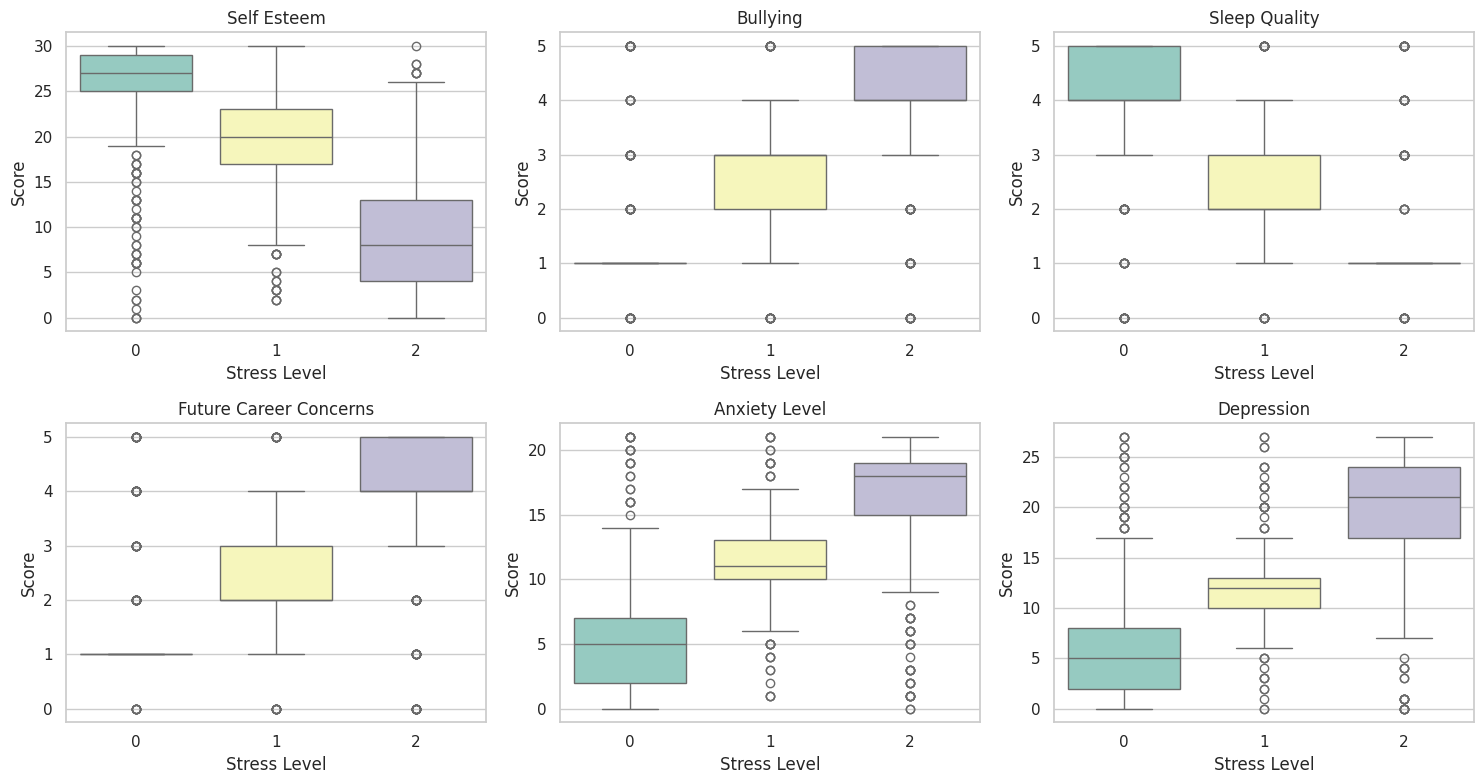

In [15]:
top_features = target_correlation.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, top_features):
    sns.boxplot(data=df, x="stress_level", y=col, ax=ax, palette="Set3")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Stress Level")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

## Preprocessing, Feature Engineering, Feature Selection, PCA, and Train/Test Split

In [16]:
df_model = df.copy()

# Row-wise feature engineering. These features combine related questionnaire items
# into broader stress indicators while keeping the original features available.
df_model["physical_symptoms_score"] = (
    df_model["headache"]
    + df_model["breathing_problem"]
    + (5 - df_model["sleep_quality"])
) / 3

df_model["academic_pressure_score"] = (
    df_model["study_load"]
    + df_model["future_career_concerns"]
    + df_model["peer_pressure"]
    + df_model["extracurricular_activities"]
) / 4

df_model["environmental_stress_score"] = (
    df_model["noise_level"]
    + (5 - df_model["living_conditions"])
    + (5 - df_model["safety"])
    + (5 - df_model["basic_needs"])
    + df_model["bullying"]
) / 5

df_model["psychological_risk_score"] = (
    df_model["anxiety_level"] / 21
    + df_model["depression"] / 27
    + (30 - df_model["self_esteem"]) / 30
) / 3

engineered_columns = [
    "physical_symptoms_score",
    "academic_pressure_score",
    "environmental_stress_score",
    "psychological_risk_score",
]

print("Engineered features added:")
display(df_model[engineered_columns].head())

print("Original feature count:", df.drop(columns=["stress_level"]).shape[1])
print("Feature count after engineering:", df_model.drop(columns=["stress_level"]).shape[1])

print("\nAll input columns are numeric, so no categorical encoding is needed.")
print("Target labels are already encoded as 0=Low, 1=Medium, and 2=High.")

X = df_model.drop(columns=["stress_level"])
y = df_model["stress_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("proportion"))
print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).sort_index().to_frame("proportion"))

Engineered features added:


,physical_symptoms_score,academic_pressure_score,environmental_stress_score,psychological_risk_score
0,3.000000,2.75,2.2,0.469136
1,4.333333,4.50,3.6,0.667725
2,2.333333,2.50,2.4,0.496649
3,3.666667,4.00,3.6,0.639153
4,1.000000,2.50,2.8,0.362610


Original feature count: 20
Feature count after engineering: 24

All input columns are numeric, so no categorical encoding is needed.
Target labels are already encoded as 0=Low, 1=Medium, and 2=High.
Training feature shape: (880, 24)
Testing feature shape: (220, 24)

Training target distribution:


,proportion
stress_level,
0,0.339773
1,0.325000
2,0.335227



Testing target distribution:


,proportion
stress_level,
0,0.336364
1,0.327273
2,0.336364


,component,cumulative_explained_variance
0,1,0.644188
1,2,0.694672
2,3,0.727452
3,4,0.753932
4,5,0.778687
5,6,0.802235
6,7,0.824401
7,8,0.844077
8,9,0.862507
9,10,0.880436


Number of PCA components needed for at least 95% variance: 15


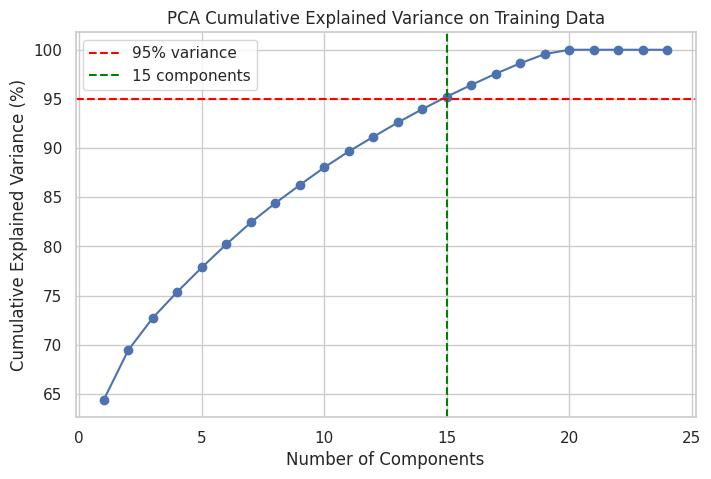

In [17]:
pca_scaler = StandardScaler()
X_train_scaled_for_pca = pca_scaler.fit_transform(X_train)

pca = PCA()
pca.fit(X_train_scaled_for_pca)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

pca_summary = pd.DataFrame({
    "component": range(1, len(cumulative_variance) + 1),
    "cumulative_explained_variance": cumulative_variance,
})

display(pca_summary.head(10))
print(f"Number of PCA components needed for at least 95% variance: {n_components_95}")

plt.figure(figsize=(8, 5))
plt.plot(
    pca_summary["component"],
    pca_summary["cumulative_explained_variance"] * 100,
    marker="o",
)
plt.axhline(y=95, color="red", linestyle="--", label="95% variance")
plt.axvline(x=n_components_95, color="green", linestyle="--", label=f"{n_components_95} components")
plt.title("PCA Cumulative Explained Variance on Training Data")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.legend()
plt.show()

# Part B: Model Training

We chose six classification algorithms to be trained and tuned:


1.   Logistic Regression
2.   Decision Tree
3.   Random Forest
4.   Support Vector Machine
5.   k-Nearest Neighbors
6.   Gradient Boosting





In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "params": {
            "feature_selection__k": [8, 12, 15, "all"],
            "model__C": [0.1, 1, 10],
        },
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "params": {
            "feature_selection__k": [8, 12, 15, "all"],
            "model__max_depth": [3, 5, None],
            "model__min_samples_split": [2, 10],
        },
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {
            "feature_selection__k": [8, 12, 15, "all"],
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, None],
        },
    },
    "SVM": {
        "estimator": SVC(random_state=RANDOM_STATE),
        "params": {
            "feature_selection__k": [8, 12, 15, "all"],
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"],
        },
    },
    "kNN": {
        "estimator": KNeighborsClassifier(),
        "params": {
            "feature_selection__k": [8, 12, 15, "all"],
            "model__n_neighbors": [3, 5, 7, 9],
            "model__weights": ["uniform", "distance"],
        },
    },
    "Gradient Boosting": {
        "estimator": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "params": {
            "feature_selection__k": [8, 12, 15, "all"],
            "model__n_estimators": [100, 150],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3],
        },
    },
}

trained_models = {}
results = []

for model_name, model_info in models.items():
    print(f"Training {model_name}...")

    pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("feature_selection", SelectKBest(score_func=f_classif)),
        ("model", model_info["estimator"]),
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=model_info["params"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=1,
    )

    grid_search.fit(X_train, y_train)
    y_pred = grid_search.predict(X_test)

    trained_models[model_name] = grid_search

    results.append({
        "model": model_name,
        "best_cv_f1_macro": grid_search.best_score_,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision_macro": precision_score(y_test, y_pred, average="macro"),
        "test_recall_macro": recall_score(y_test, y_pred, average="macro"),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro"),
        "best_params": grid_search.best_params_,
    })

results_df = pd.DataFrame(results).sort_values("test_f1_macro", ascending=False)
display(results_df)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training SVM...
Training kNN...
Training Gradient Boosting...


,model,best_cv_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,best_params
0,Logistic Regression,0.882200,0.886364,0.886976,0.886637,0.886778,"{'feature_selection__k': 'all', 'model__C': 0.1}"
4,kNN,0.892228,0.886364,0.886618,0.886637,0.886437,"{'feature_selection__k': 15, 'model__n_neighbo..."
2,Random Forest,0.885349,0.881818,0.882439,0.882007,0.881145,"{'feature_selection__k': 'all', 'model__max_de..."
1,Decision Tree,0.880391,0.877273,0.877503,0.877503,0.877503,"{'feature_selection__k': 8, 'model__max_depth'..."
5,Gradient Boosting,0.883140,0.872727,0.873016,0.872998,0.872649,"{'feature_selection__k': 8, 'model__learning_r..."
3,SVM,0.884073,0.868182,0.869843,0.868368,0.868855,"{'feature_selection__k': 12, 'model__C': 1, 'm..."


# Model Evaluation & Comparison
We evaluated the models' performance using parameters such as accuracy, F1 score, precision and recall.

,model,best_cv_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,Logistic Regression,0.882200,0.886364,0.886976,0.886637,0.886778
4,kNN,0.892228,0.886364,0.886618,0.886637,0.886437
2,Random Forest,0.885349,0.881818,0.882439,0.882007,0.881145
1,Decision Tree,0.880391,0.877273,0.877503,0.877503,0.877503
5,Gradient Boosting,0.883140,0.872727,0.873016,0.872998,0.872649
3,SVM,0.884073,0.868182,0.869843,0.868368,0.868855


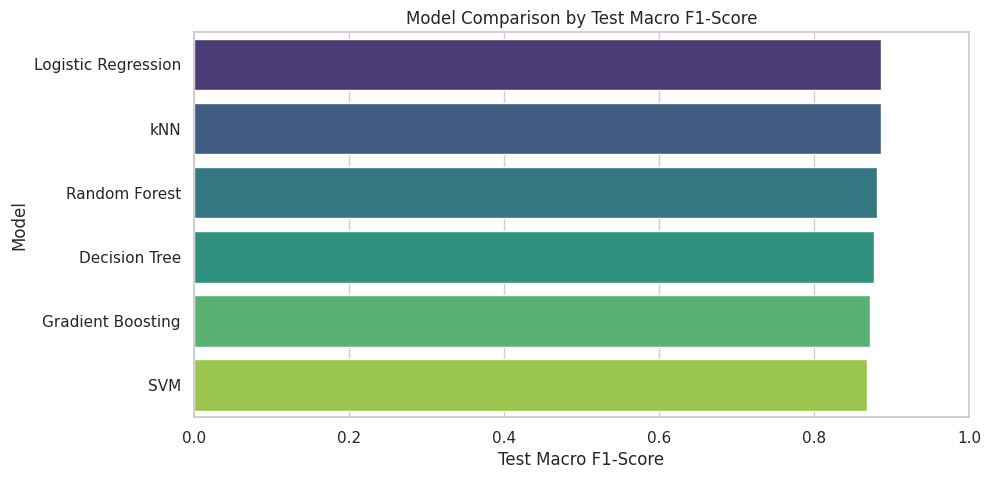

In [20]:
metric_columns = [
    "best_cv_f1_macro",
    "test_accuracy",
    "test_precision_macro",
    "test_recall_macro",
    "test_f1_macro",
]

display(results_df[["model"] + metric_columns])

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="test_f1_macro", y="model", palette="viridis")
plt.title("Model Comparison by Test Macro F1-Score")
plt.xlabel("Test Macro F1-Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

In [21]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_predictions = best_model.predict(X_test)

print("Best model:", best_model_name)
print("\nBest parameters:")
display(best_model.best_params_)

print("\nClassification report:")
print(classification_report(y_test, best_predictions, target_names=["Low Stress", "Medium Stress", "High Stress"]))

Best model: Logistic Regression

Best parameters:


{'feature_selection__k': 'all', 'model__C': 0.1}


Classification report:
               precision    recall  f1-score   support

   Low Stress       0.85      0.85      0.85        74
Medium Stress       0.93      0.92      0.92        72
  High Stress       0.88      0.89      0.89        74

     accuracy                           0.89       220
    macro avg       0.89      0.89      0.89       220
 weighted avg       0.89      0.89      0.89       220



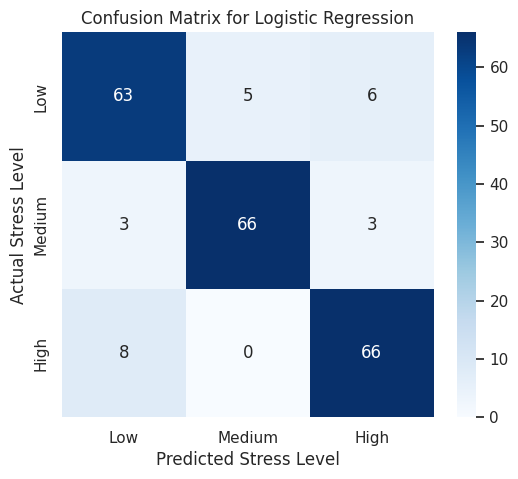

In [22]:
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
)
plt.title(f"Confusion Matrix for {best_model_name}")
plt.xlabel("Predicted Stress Level")
plt.ylabel("Actual Stress Level")
plt.show()

# Feature Importance

Selected features used by the best model:


,selected_feature
0,anxiety_level
1,self_esteem
2,mental_health_history
3,depression
4,headache
5,blood_pressure
6,sleep_quality
7,breathing_problem
8,noise_level
9,living_conditions


,feature,selection_score
22,environmental_stress_score,1137.699088
21,academic_pressure_score,1025.808910
23,psychological_risk_score,1015.294146
20,physical_symptoms_score,917.673413
5,blood_pressure,823.730390
1,self_esteem,625.438459
19,bullying,588.842939
6,sleep_quality,568.472492
0,anxiety_level,553.438806
12,academic_performance,552.889246


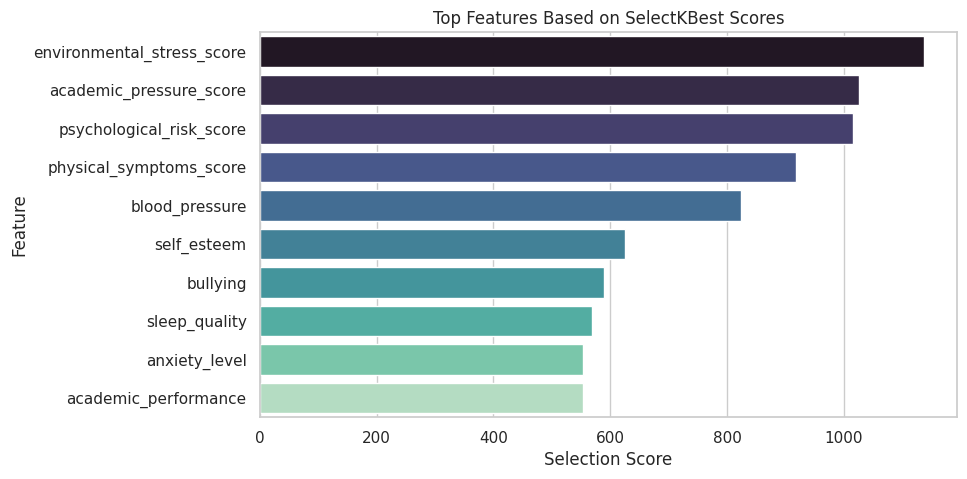

In [23]:
best_pipeline = best_model.best_estimator_
selector = best_pipeline.named_steps["feature_selection"]
selected_features = X_train.columns[selector.get_support()].tolist()

print("Selected features used by the best model:")
display(pd.DataFrame({"selected_feature": selected_features}))

final_estimator = best_pipeline.named_steps["model"]

if hasattr(final_estimator, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": selected_features,
        "importance": final_estimator.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importance_df)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=importance_df.head(10), x="importance", y="feature", palette="mako")
    plt.title(f"Top Feature Importances for {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    scores_df = pd.DataFrame({
        "feature": X_train.columns,
        "selection_score": selector.scores_,
    }).sort_values("selection_score", ascending=False)

    display(scores_df.head(10))

    plt.figure(figsize=(9, 5))
    sns.barplot(data=scores_df.head(10), x="selection_score", y="feature", palette="mako")
    plt.title("Top Features Based on SelectKBest Scores")
    plt.xlabel("Selection Score")
    plt.ylabel("Feature")
    plt.show()

# Results Discussion
The best model is selected using test macro F1-score because macro F1 balances precision and recall across all three stress classes.
The selected features and feature importance chart help explain which student-related factors contribute most strongly to the prediction. Features such as anxiety, depression, self-esteem, academic performance, sleep quality, social support, bullying, and future career concerns are especially meaningful for a stress-level prediction problem because they represent psychological, academic, and social influences.

The engineered features make the model inputs easier to understand at a higher level. For example, physical symptoms, academic pressure, environmental stress, and psychological risk summarize groups of related questionnaire responses. PCA was also checked as a dimensionality reduction method, but the final model uses SelectKBest so the selected features remain interpretable.

The model should be interpreted as a decision-support tool, not as a medical diagnosis tool. The dataset is useful for learning machine learning methods, but real-world stress screening would require professional validation, ethical approval, and careful handling of sensitive student information.

# Student Risk Profile
To make the project more practical and innovative, this section turns the trained model into a simple decision-support demonstration. It adds three useful outputs:
a student risk profile;
model confidence using predicted probabilities;
what-if analysis to show how changes in student conditions may affect predicted stress level.

In [35]:
class_names = {
    0: "Low Stress",
    1: "Medium Stress",
    2: "High Stress",
}

risk_profile_map = {
    0: "Low Risk - routine monitoring is enough",
    1: "Moderate Risk - student may benefit from academic or social support",
    2: "High Risk - student may need early support or referral to counselling services",
}

example_index = X_test.sample(1).index[0]
example_student = X_test.loc[[example_index]].copy()
actual_class = y_test.loc[example_index]

predicted_class = int(best_model.predict(example_student)[0])
predicted_label = class_names[predicted_class]
risk_profile = risk_profile_map[predicted_class]

print("Example student index:", example_index)
print("Actual stress level:", class_names[int(actual_class)])
print("Predicted stress level:", predicted_label)
print("Risk profile:", risk_profile)

Example student index: 155
Actual stress level: Medium Stress
Predicted stress level: Medium Stress
Risk profile: Moderate Risk - student may benefit from academic or social support


# Try Your Own Stress Prediction
Use the expected ranges below:

anxiety_level: 0 to 21

self_esteem: 0 to 30

depression: 0 to 27

mental_health_history: 0 or 1

blood_pressure: 1 to 3

social_support: 0 to 3

most other score columns: 0 to 5

In [44]:
def ask_numeric_value(question_text, feature_name, minimum, maximum, default):
    prompt = f"{question_text} ({minimum}-{maximum}): "

    while True:
        try:
            user_text = input(prompt).strip()
        except (EOFError, NotImplementedError):
            print(f"No interactive input available. Using sample value for {feature_name}: {default}")
            return default
        except Exception as error:
            if error.__class__.__name__ == "StdinNotImplementedError":
                print(f"No interactive input available. Using sample value for {feature_name}: {default}")
                return default
            raise

        if user_text == "":
            print("Please enter a value before continuing.")
            continue

        try:
            value = float(user_text)
        except ValueError:
            print("Please enter a number.")
            continue

        if minimum <= value <= maximum:
            return value

        print(f"Please enter a value from {minimum} to {maximum}.")


print("Enter your own values below to predict stress level.")
print("Type a number for each question, then press Enter.\n")

input_questions = [
    ("How anxious do you feel recently?", "anxiety_level", 0, 21, 12),
    ("How would you rate your self-esteem? Higher means better self-esteem", "self_esteem", 0, 30, 16),
    ("Do you have a mental health history? Enter 0 for No or 1 for Yes", "mental_health_history", 0, 1, 0),
    ("How much depression or low mood have you experienced recently?", "depression", 0, 27, 10),
    ("How often do you experience headaches?", "headache", 0, 5, 2),
    ("What is your blood pressure level? 1=Low, 2=Normal, 3=High", "blood_pressure", 1, 3, 2),
    ("How good is your sleep quality? Higher means better sleep", "sleep_quality", 0, 5, 3),
    ("How often do you experience breathing problems?", "breathing_problem", 0, 5, 2),
    ("How noisy is your environment?", "noise_level", 0, 5, 2),
    ("How good are your living conditions? Higher means better conditions", "living_conditions", 0, 5, 3),
    ("How safe do you feel in your environment? Higher means safer", "safety", 0, 5, 3),
    ("How well are your basic needs met? Higher means better", "basic_needs", 0, 5, 3),
    ("How good is your academic performance? Higher means better performance", "academic_performance", 0, 5, 3),
    ("How heavy is your study load?", "study_load", 0, 5, 3),
    ("How good is your relationship with teachers? Higher means better relationship", "teacher_student_relationship", 0, 5, 3),
    ("How worried are you about your future career?", "future_career_concerns", 0, 5, 3),
    ("How much social support do you receive?", "social_support", 0, 3, 2),
    ("How much peer pressure do you experience?", "peer_pressure", 0, 5, 2),
    ("How much pressure do extracurricular activities create for you?", "extracurricular_activities", 0, 5, 2),
    ("How much bullying have you experienced?", "bullying", 0, 5, 1),
]

my_profile = {}
for question_text, feature_name, minimum, maximum, default in input_questions:
    my_profile[feature_name] = ask_numeric_value(question_text, feature_name, minimum, maximum, default)

my_profile_df = pd.DataFrame([my_profile])
my_profile_features = add_engineered_features(my_profile_df)

my_prediction = int(best_model.predict(my_profile_features)[0])
my_prediction_label = class_names[my_prediction]
my_risk_profile = risk_profile_map[my_prediction]

print("Predicted stress level:", my_prediction_label)
print("Risk profile:", my_risk_profile)
print("\nInput values used:")
display(my_profile_df)

if hasattr(best_model.best_estimator_.named_steps["model"], "predict_proba"):
    my_probabilities = best_model.predict_proba(my_profile_features)[0]
    my_confidence_df = pd.DataFrame({
        "stress_level": [class_names[i] for i in best_model.classes_],
        "predicted_probability": my_probabilities,
    }).sort_values("predicted_probability", ascending=False)

    display(my_confidence_df)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=my_confidence_df, x="predicted_probability", y="stress_level", palette="crest")
    plt.title("Predicted Stress Level Confidence for Custom Input")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Stress Level")
    plt.xlim(0, 1)
    plt.show()

Enter your own values below to predict stress level.
Type a number for each question, then press Enter.



KeyboardInterrupt: Interrupted by user

# Conclusion
In this notebook, we completed the full machine learning workflow for predicting student stress levels. We inspected both datasets first, then chose `StressLevelDataset.csv` because it had a clear target column, no missing values, no duplicate rows, and fairly balanced stress-level classes.

We carried out the main preprocessing steps, including data cleaning checks, range validation, exploratory data analysis, feature engineering, PCA checking, feature selection, train/test splitting, model training, hyperparameter tuning, model comparison, and final evaluation. We trained six different machine learning models and compared their performance using suitable classification metrics.

The best model was then used to predict student stress levels and show confidence scores. We also added a few practical features, such as student risk profiling, what-if analysis, and a custom input section where users can enter their own values and get a stress-level prediction. Overall, this project shows how machine learning can be used to better understand student well-being, while remembering that the model should only be used as a support tool and not as a replacement for professional help.